# Método de Posición Falsa

Implementación y aplicación del **método de posición falsa** para aproximar raíces de ecuaciones no lineales utilizando Python.

Este notebook reúne ejercicios desarrollados durante el estudio de **Análisis Numérico**, reorganizados y documentados para presentar de forma clara el fundamento del método, su implementación y sus aplicaciones.

### Objetivos

- Comprender el fundamento del método de posición falsa.
- Implementar el método en Python.
- Aproximar raíces dentro de intervalos que presentan cambio de signo.
- Analizar el comportamiento del método mediante diferentes ejemplos.
- Visualizar geométricamente las secantes utilizadas durante el proceso.

**Tecnologías:** Python · NumPy · Matplotlib

## 1. Fundamento del método

El **método de posición falsa**, también conocido como *regula falsi*, permite aproximar una raíz de una función continua $f(x)$ dentro de un intervalo $[a,b]$.

Para aplicar el método se requiere que exista un cambio de signo entre los extremos:

$f(a)\cdot f(b)<0$

De acuerdo con el **Teorema de Bolzano**, esta condición garantiza que existe al menos una raíz dentro del intervalo.

A diferencia del método de bisección, la posición falsa no utiliza directamente el punto medio. En cada iteración se construye una recta secante entre los puntos $(a,f(a))$ y $(b,f(b))$ y se calcula su intersección con el eje $x$ mediante:

$c=b-f(b)\frac{a-b}{f(a)-f(b)}$

Después se conserva el subintervalo en el que continúa existiendo el cambio de signo y el proceso se repite hasta alcanzar la tolerancia establecida.

## 2. Implementación del método

La siguiente función corresponde a la implementación utilizada para resolver los ejercicios del notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def PosicionFalsa(FuncionObjetivo, ExtremoIzquierdo, ExtremoDerecho, Tolerancia):

    # Verifica que el intervalo [a, b] contenga una raíz
    if (FuncionObjetivo(ExtremoIzquierdo) * FuncionObjetivo(ExtremoDerecho) > 0):
        print("La función no cumple el teorema en el intervalo, busque otro [a,b]")
    else:
        print("Buscando el cero f(x) = 0...")

        # Primera aproximación de la raíz mediante posición falsa
        c = ExtremoDerecho - FuncionObjetivo(ExtremoDerecho) * (ExtremoIzquierdo - ExtremoDerecho) / (FuncionObjetivo(ExtremoIzquierdo) - FuncionObjetivo(ExtremoDerecho))
        i = 0

        # Continúa mientras la longitud del intervalo sea mayor que la tolerancia
        while (abs(ExtremoDerecho - ExtremoIzquierdo) > Tolerancia):

            # Nueva aproximación: intersección de la secante con el eje x
            c = ExtremoDerecho - FuncionObjetivo(ExtremoDerecho) * (ExtremoIzquierdo - ExtremoDerecho) / (FuncionObjetivo(ExtremoIzquierdo) - FuncionObjetivo(ExtremoDerecho))
            i += 1

            # Si f(c) está suficientemente cerca de cero, termina el método
            if abs(FuncionObjetivo(c)) < Tolerancia:
                print("C =", c, "Iteraciones:", i)
                return c, i

            # Si la raíz se encuentra entre [a, c], actualiza el extremo derecho
            if (FuncionObjetivo(ExtremoIzquierdo) * FuncionObjetivo(c) < 0):
                ExtremoDerecho = c
            else:
                # De lo contrario, la raíz se encuentra entre [c, b]
                ExtremoIzquierdo = c

        # Si termina por reducción del intervalo, muestra su longitud final
        print(ExtremoDerecho - ExtremoIzquierdo)

## 3. Ejemplo 1 — Raíz de una función polinómica

Se desea aproximar una raíz de la función:

$f(x)=x^{10}-1$

utilizando el intervalo $[0,3]$ y una tolerancia de $10^{-8}$.

En este intervalo se cumple que $f(0)<0$ y $f(3)>0$, por lo que existe un cambio de signo y es posible aplicar el método de posición falsa.

La raíz esperada se encuentra en $x=1$.

In [2]:
FuncionObjetivo = lambda valor_x: valor_x**10 - 1
ExtremoIzquierdo = 0
ExtremoDerecho = 3
Tolerancia = 1e-8

Raiz, Iteraciones = PosicionFalsa(
    FuncionObjetivo,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

Buscando el cero f(x) = 0...
C = 0.999999999000257 Iteraciones: 77677


### Observación

En este ejemplo, el método de posición falsa requiere un número elevado de iteraciones para alcanzar la tolerancia establecida. Esto ocurre porque los valores de la función en los extremos del intervalo presentan magnitudes muy diferentes, lo que provoca que uno de los extremos se actualice lentamente. Este comportamiento permite observar una de las posibles limitaciones del método de posición falsa en determinadas funciones e intervalos.

## 4. Aplicación 1 — Problema de dos números

La suma de dos números es $20$. Si a cada número se le suma su raíz cuadrada, el producto de las dos expresiones resultantes es $155.55$.

Se desea determinar ambos números con una exactitud de $10^{-8}$.

Si los números son $x$ y $y$:

$x+y=20$

Además:

$(x+\sqrt{x})(y+\sqrt{y})=155.55$

Como $y=20-x$, se obtiene una ecuación en una sola variable:

$(x+\sqrt{x})(20-x+\sqrt{20-x})-155.55=0$

Esta expresión se utiliza como función objetivo para aplicar el método de posición falsa.

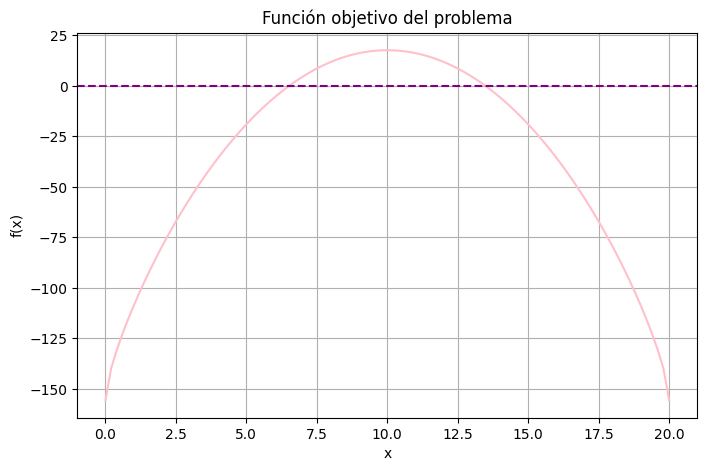

Buscando el cero f(x) = 0...
C = 6.51284872645613 Iteraciones: 13
Primer número aproximado: 6.5128487265
Segundo número aproximado: 13.4871512735
Suma de ambas aproximaciones: 20.0000000000
Iteraciones: 13


In [3]:
FuncionObjetivo = lambda valor_x: (valor_x + np.sqrt(valor_x)) * (20 - valor_x + np.sqrt(20 - valor_x)) - 155.55

ExtremoIzquierdo = 5
ExtremoDerecho = 7.5
Tolerancia = 1e-8

# Visualización de la función en el dominio permitido
array_x = np.linspace(0, 20, 100)

plt.figure(figsize=(8, 5))
plt.plot(array_x, FuncionObjetivo(array_x), 'pink')
plt.grid()
plt.axhline(0, linestyle='--', color='purple')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función objetivo del problema")
plt.show()

# Aplicación del método
Numero1, Iteraciones = PosicionFalsa(
    FuncionObjetivo,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

# El segundo número se obtiene a partir de la condición x + y = 20
Numero2 = 20 - Numero1
suma = Numero1 + Numero2

print(f"Primer número aproximado: {Numero1:.10f}")
print(f"Segundo número aproximado: {Numero2:.10f}")
print(f"Suma de ambas aproximaciones: {suma:.10f}")
print(f"Iteraciones: {Iteraciones}")

## 5. Visualización geométrica del método

Para visualizar el funcionamiento de la posición falsa se utiliza la función:

$f(x)=x^2-4$

en el intervalo $[1,3]$.

En cada iteración se dibuja la secante que une los extremos actuales del intervalo. La intersección de esta secante con el eje $x$ corresponde a la nueva aproximación $c$.

Buscando el cero f(x) = 0...
Iteración 1: c = 1.7500000000
Iteración 2: c = 1.9473684211
Iteración 3: c = 1.9893617021
Iteración 4: c = 1.9978678038
Iteración 5: c = 1.9995733788
Iteración 6: c = 1.9999146685
Iteración 7: c = 1.9999829334
Iteración 8: c = 1.9999965867
Iteración 9: c = 1.9999993173
Iteración 10: c = 1.9999998635
Iteración 11: c = 1.9999999727
Iteración 12: c = 1.9999999945
Iteración 13: c = 1.9999999989

Raíz aproximada: 1.9999999989
Iteraciones: 13


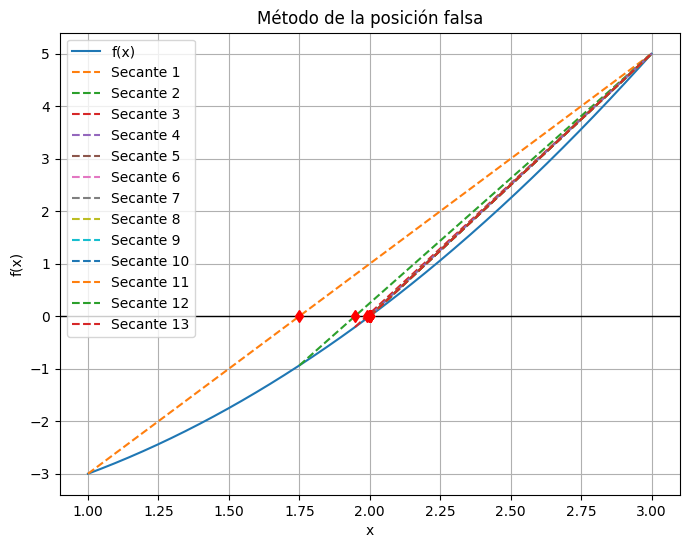

In [4]:
FuncionObjetivo = lambda valor_x: valor_x**2 - 4

ExtremoIzquierdo = 1
ExtremoDerecho = 3
Tolerancia = 1e-8

def PosicionFalsaGrafica(FuncionObjetivo, ExtremoIzquierdo, ExtremoDerecho, Tolerancia):
    # Misma lógica del método original, incorporando su representación gráfica
    if (FuncionObjetivo(ExtremoIzquierdo) * FuncionObjetivo(ExtremoDerecho) > 0):
        print("La función no cumple el teorema en el intervalo, busque otro [a,b]")
        return

    print("Buscando el cero f(x) = 0...")

    x_vals = np.linspace(ExtremoIzquierdo, ExtremoDerecho, 400)
    y_vals = FuncionObjetivo(x_vals)

    plt.figure(figsize=(8, 6))
    plt.axhline(0, color='black', linewidth=1)
    plt.plot(x_vals, y_vals, label="f(x)")

    i = 0

    while (abs(ExtremoDerecho - ExtremoIzquierdo) > Tolerancia):
        c = ExtremoDerecho - FuncionObjetivo(ExtremoDerecho) * (ExtremoIzquierdo - ExtremoDerecho) / (FuncionObjetivo(ExtremoIzquierdo) - FuncionObjetivo(ExtremoDerecho))
        i += 1

        print(f"Iteración {i}: c = {c:.10f}")

        # Secante utilizada en la iteración
        plt.plot(
            [ExtremoIzquierdo, ExtremoDerecho],
            [FuncionObjetivo(ExtremoIzquierdo), FuncionObjetivo(ExtremoDerecho)],
            '--',
            label=f"Secante {i}"
        )
        plt.plot(c, 0, 'rd')

        if abs(FuncionObjetivo(c)) < Tolerancia:
            break

        if (FuncionObjetivo(ExtremoIzquierdo) * FuncionObjetivo(c) < 0):
            ExtremoDerecho = c
        else:
            ExtremoIzquierdo = c

    print(f"\nRaíz aproximada: {c:.10f}")
    print(f"Iteraciones: {i}")

    plt.legend()
    plt.title("Método de la posición falsa")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.show()

PosicionFalsaGrafica(
    FuncionObjetivo,
    ExtremoIzquierdo,
    ExtremoDerecho,
    Tolerancia
)

## 6. Conclusiones

El método de posición falsa permite aproximar raíces utilizando la intersección de una secante con el eje $x$ y conservando siempre un intervalo que contiene un cambio de signo.

A partir de los ejercicios desarrollados se observa que:

- El método utiliza el criterio de cambio de signo asociado al Teorema de Bolzano.
- La nueva aproximación depende de los valores de la función en ambos extremos del intervalo.
- El número de iteraciones puede variar considerablemente según la función y el intervalo inicial.
- La representación gráfica de las secantes ayuda a comprender cómo evoluciona la aproximación hacia la raíz.
- El método puede utilizarse tanto en ejemplos matemáticos como en problemas planteados mediante ecuaciones no lineales.